In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import calendar

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

with open('usda_cream_classii_midwest_1996_2026.json') as f:
    records = json.load(f)

df = pd.DataFrame(records)
df['report_date'] = pd.to_datetime(df['report_date'], format='%m/%d/%Y')
df['spread'] = df['price_max'] - df['price_min']

print(f"Dataset: {len(df):,} records — Cream x Class II x Midwest")
print(f"Date range: {df['report_date'].min().date()} to {df['report_date'].max().date()}")
df[['report_date','year','month','price_min','price_max','spread']].head()

Dataset: 2,003 records — Cream x Class II x Midwest
Date range: 1996-01-01 to 2026-04-27


,report_date,year,month,price_min,price_max,spread
0,1996-01-01,1996,1,1.0419,1.0947,0.0528
1,1996-01-08,1996,1,1.0419,1.0947,0.0528
2,1996-01-15,1996,1,0.9450,1.0350,0.0900
3,1996-01-22,1996,1,0.9450,1.0350,0.0900
4,1996-01-29,1996,1,0.8946,0.9798,0.0852


## 1. Records per Year

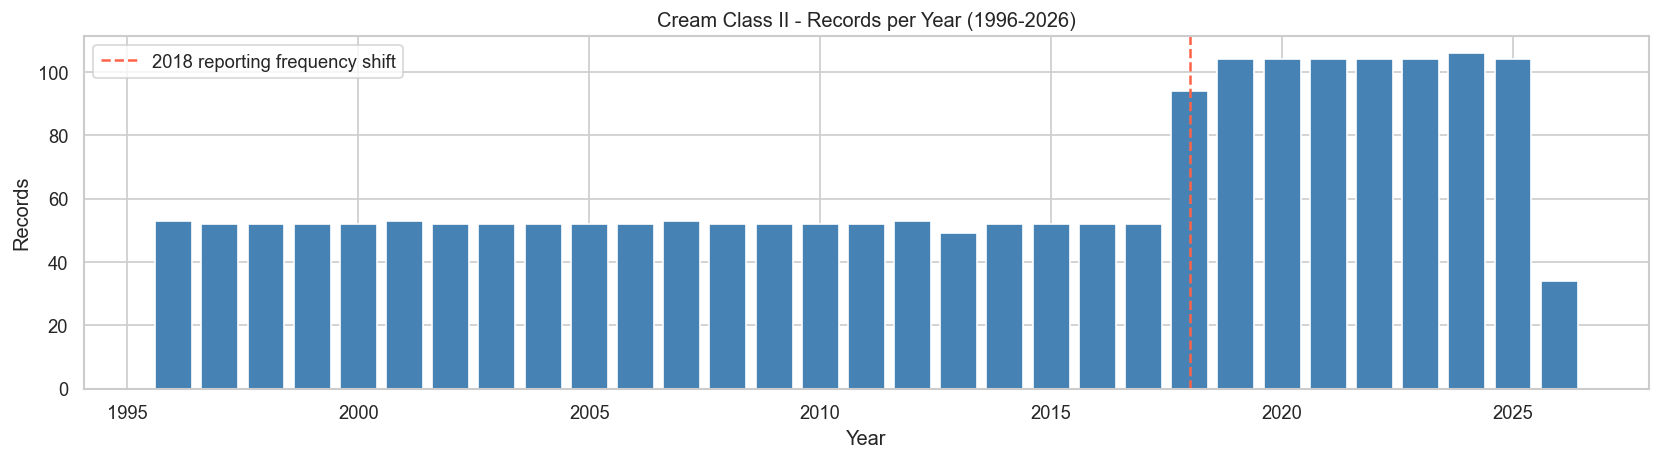

In [2]:
counts = df.groupby('year').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.axvline(2018, color='tomato', linestyle='--', linewidth=1.5, label='2018 reporting frequency shift')
ax.set_xlabel('Year')
ax.set_ylabel('Records')
ax.set_title('Cream Class II - Records per Year (1996-2026)')
ax.legend()
plt.tight_layout()
plt.show()

**What this means for you:**

Each bar shows how many times the USDA published a cream price in that year. Before 2018, they published once a week. Starting in 2019, they started publishing twice a week — that's why the bars get taller after the red dotted line. The data itself didn't change; the government just started reporting more frequently. For our forecasting model, we use data from 2019 onwards so everything is consistent.

## 2. Full Price History - Annual Average Band

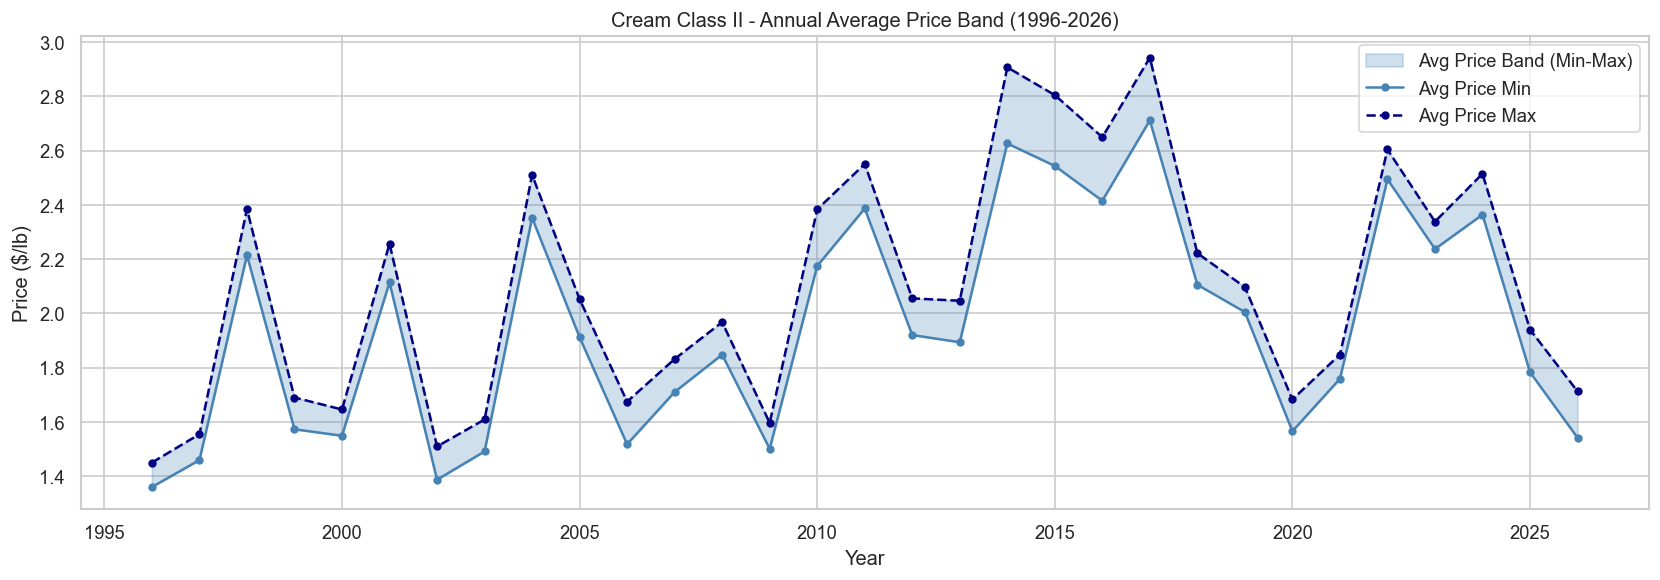

In [3]:
ann = df.groupby('year').agg(
    price_min_mean=('price_min','mean'),
    price_max_mean=('price_max','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(ann['year'], ann['price_min_mean'], ann['price_max_mean'],
                alpha=0.25, color='steelblue', label='Avg Price Band (Min-Max)')
ax.plot(ann['year'], ann['price_min_mean'], marker='o', markersize=4,
        color='steelblue', label='Avg Price Min')
ax.plot(ann['year'], ann['price_max_mean'], marker='o', markersize=4,
        color='navy', linestyle='--', label='Avg Price Max')
ax.set_xlabel('Year')
ax.set_ylabel('Price ($/lb)')
ax.set_title('Cream Class II - Annual Average Price Band (1996-2026)')
ax.legend()
plt.tight_layout()
plt.show()

**What this means for you:**

This is the big picture — 30 years of cream prices in one chart. The shaded band shows the range between the lowest and highest price reported each year. A wider band means prices were more unpredictable that year; a narrow band means prices were stable.

Key things to notice:
- Prices spiked sharply around **2004, 2011, and 2022** — those were years of major supply squeezes or demand surges.
- The **2022 spike** is the highest on record (~$4.50/lb), driven by post-COVID supply chain disruptions.
- Prices have since come back down but remain elevated compared to the pre-2020 average of ~$1.50–$2.00/lb.

For an ice cream business like Sneehee's, this chart tells the story: cream has always been volatile, but recent years have been especially unpredictable — which is exactly why a forecasting tool matters.

## 3. Price Distribution by Decade

/var/folders/_c/lfjbbcy12158wfvcz1p0_3d00000gn/T/ipykernel_25737/2451283831.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='decade', y='price_min', ax=axes[1],


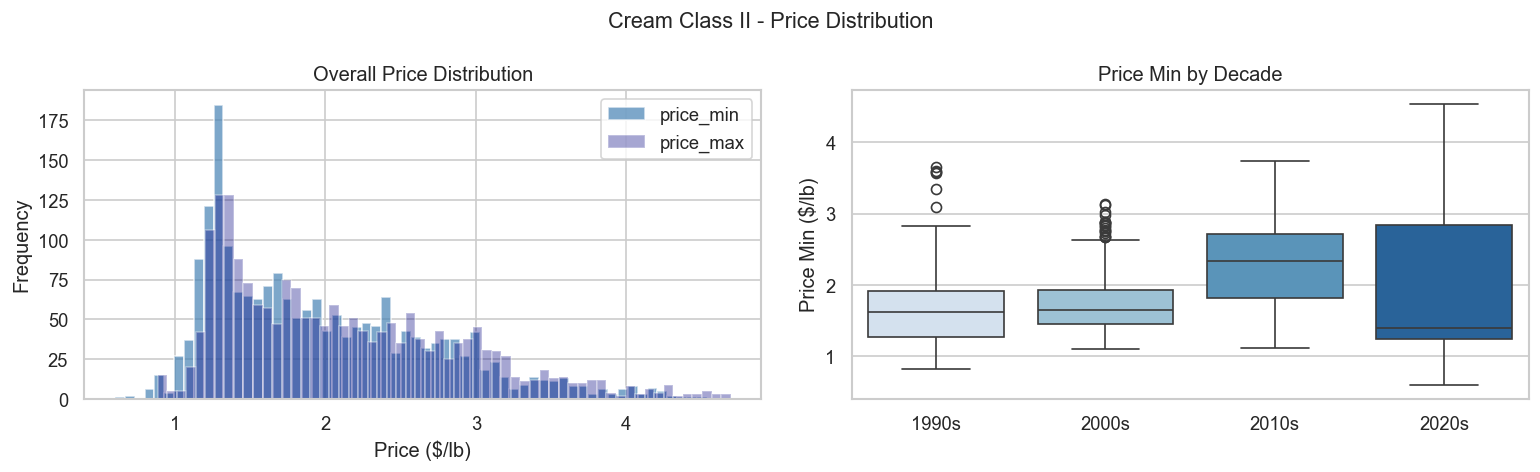

In [4]:
df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'
decade_order = ['1990s','2000s','2010s','2020s']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price_min'], bins=60, color='steelblue', alpha=0.7, label='price_min')
axes[0].hist(df['price_max'], bins=60, color='navy', alpha=0.35, label='price_max')
axes[0].set_xlabel('Price ($/lb)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Price Distribution')
axes[0].legend()

sns.boxplot(data=df, x='decade', y='price_min', ax=axes[1],
            palette='Blues', order=decade_order)
axes[1].set_title('Price Min by Decade')
axes[1].set_ylabel('Price Min ($/lb)')
axes[1].set_xlabel('')

plt.suptitle('Cream Class II - Price Distribution', fontsize=13)
plt.tight_layout()
plt.show()

**What this means for you:**

**Left chart:** Think of it as a histogram of how often cream lands at each price. The big hump around $1.00–$2.00/lb is where prices spent most of the last 30 years. The long tail to the right shows that high prices ($3–$4.50/lb) do happen — they're rare but real.

**Right chart (boxes by decade):** Each box shows the typical price range for that decade. The line in the middle of the box is the most common price. The dots above the box are outlier spikes — unusually expensive years.
- 1990s and 2000s: cream was cheap and stable, mostly under $1.50/lb.
- 2010s: prices crept up and became more unpredictable.
- 2020s: the box is higher and wider — cream is now both more expensive and harder to predict.

**Bottom line:** If you're budgeting based on what cream cost in the 2010s, you're likely underestimating your costs today.

## 4. Monthly Seasonality (all years pooled)

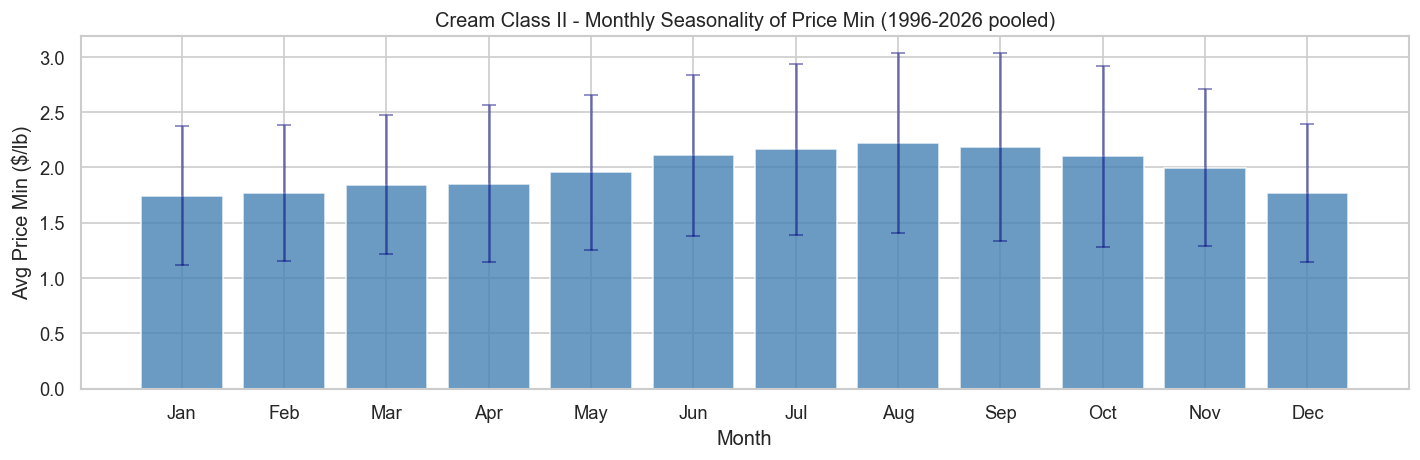

In [5]:
monthly = df.groupby('month')['price_min'].agg(['mean','std']).reset_index()
month_names = [calendar.month_abbr[m] for m in monthly['month']]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(month_names, monthly['mean'], yerr=monthly['std'], capsize=4,
       color='steelblue', alpha=0.8, error_kw={'ecolor':'navy','alpha':0.5})
ax.set_xlabel('Month')
ax.set_ylabel('Avg Price Min ($/lb)')
ax.set_title('Cream Class II - Monthly Seasonality of Price Min (1996-2026 pooled)')
plt.tight_layout()
plt.show()

**What this means for you:**

This chart answers: *does cream get more expensive at certain times of year?* Each bar is the average price for that month across all 30 years. The thin vertical line on top of each bar shows how much prices varied — a taller line means less predictable.

The pattern is relatively flat, meaning cream doesn't have a strong seasonal swing the way, say, fresh produce does. However, there is a slight tendency for prices to be a bit lower in spring (when cows produce more milk) and slightly higher in fall/winter.

**Practical takeaway for Sneehee:** If you're planning a big production run or buying cream in bulk, spring is historically your best window to lock in lower prices. The difference is modest — but on 40% of your COGS, even a 5% savings adds up.

## 5. Heatmap - Avg Price Min by Month x Year (2010-2026)

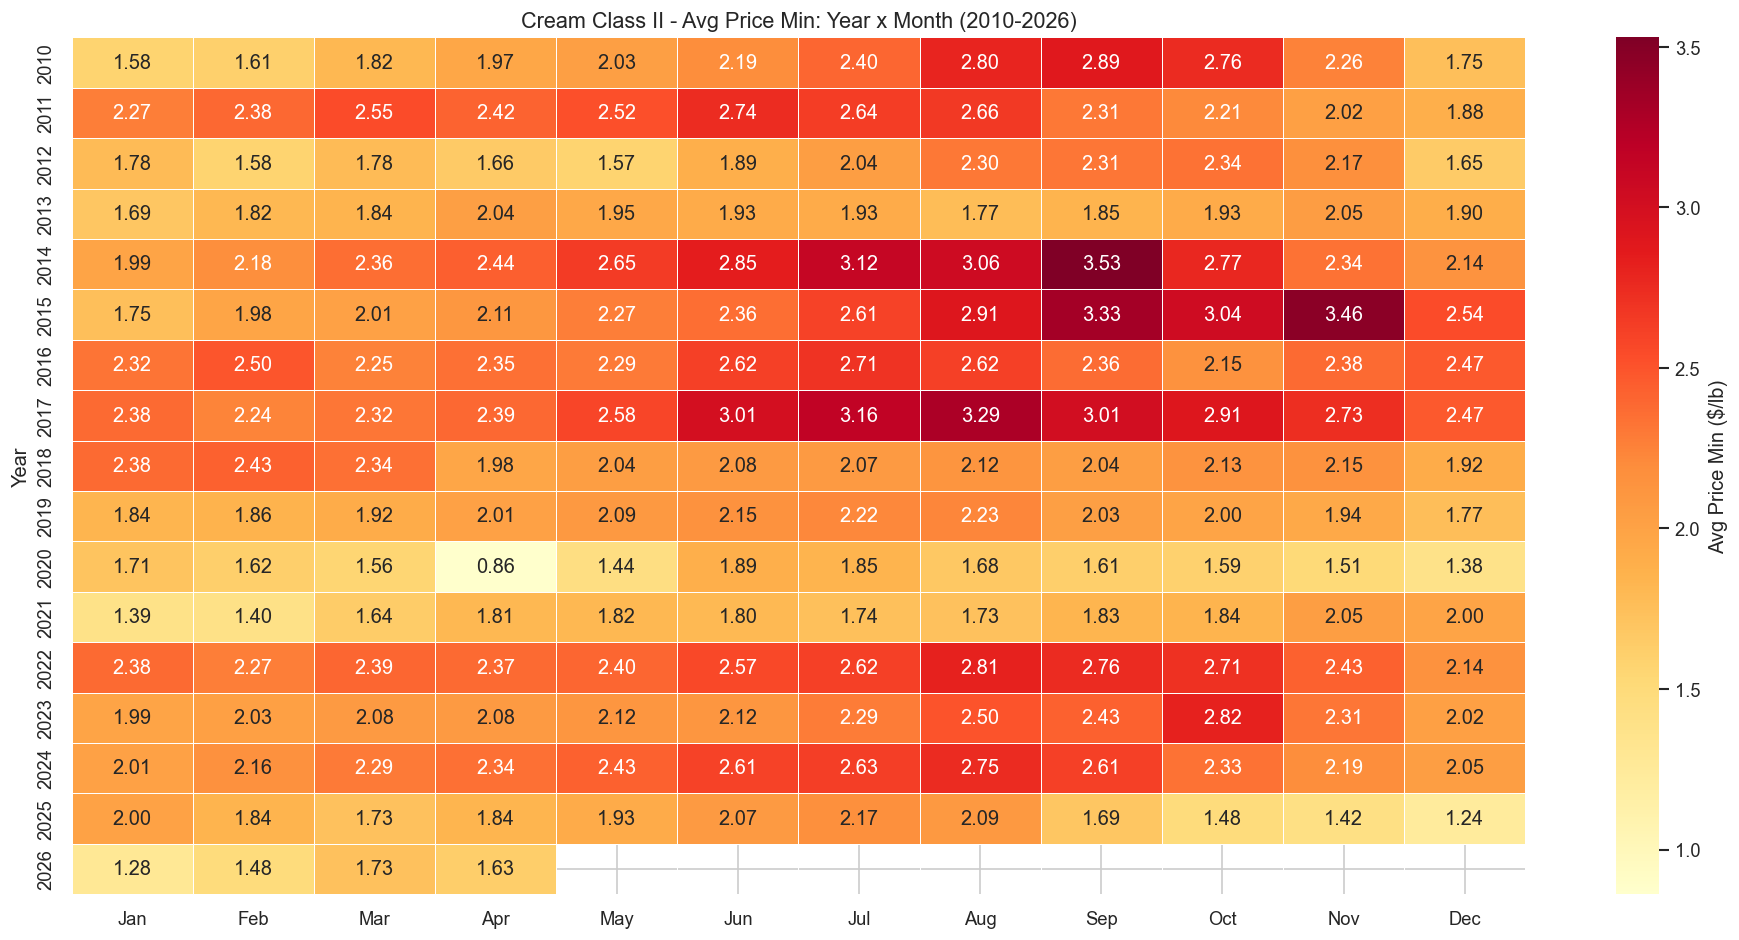

In [6]:
heat = df[df['year'] >= 2010].groupby(['year','month'])['price_min'].mean().unstack()
heat.columns = [calendar.month_abbr[m] for m in heat.columns]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(heat, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.3,
            cbar_kws={'label':'Avg Price Min ($/lb)'}, ax=ax)
ax.set_title('Cream Class II - Avg Price Min: Year x Month (2010-2026)', fontsize=13)
ax.set_ylabel('Year')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**What this means for you:**

Think of this as a calendar where every cell is color-coded by cream price. **Yellow = cheap. Dark red = expensive.**

Each row is a year; each column is a month. The number inside each cell is the actual average price in dollars per pound that month.

Key things to spot:
- **2022** is the darkest row — cream was expensive almost every single month of that year.
- **2016** is one of the lightest rows — a relatively cheap year for cream.
- You can see within each year whether prices spiked in a particular season.

**How to use this:** If you're negotiating a supplier contract or deciding when to stock up, this chart shows you at a glance which months have historically been dangerous vs. safe for cream prices.

## 6. Price Spread (Max - Min) Over Time

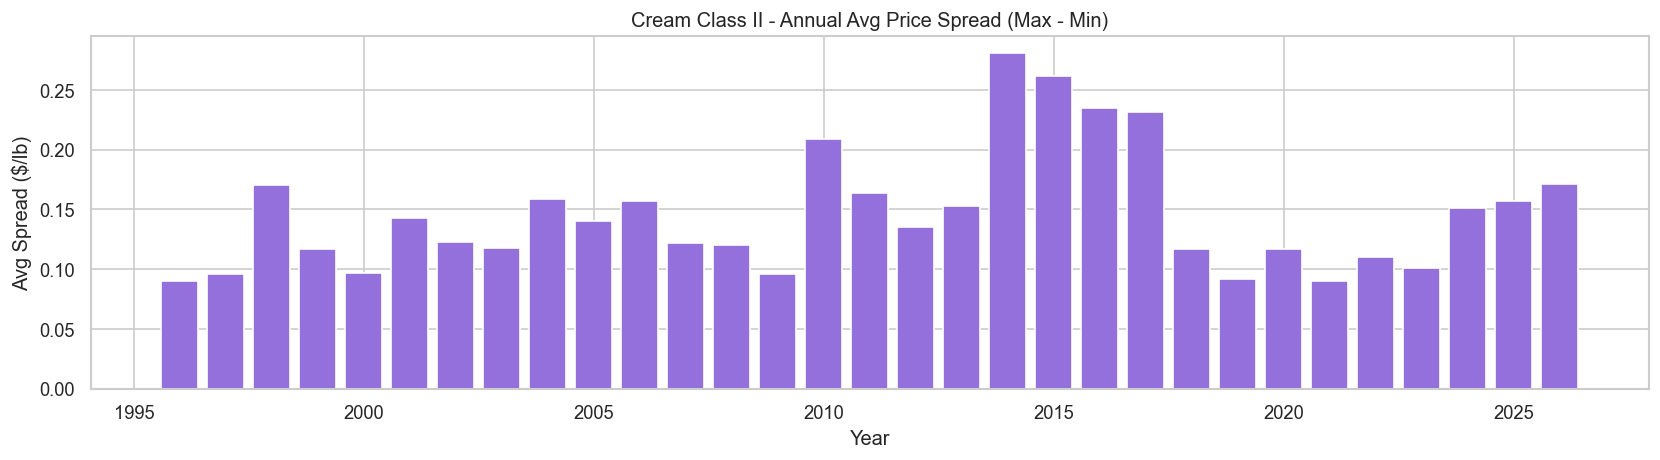

In [7]:
ann_spread = df.groupby('year')['spread'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(ann_spread.index, ann_spread.values, color='mediumpurple', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Spread ($/lb)')
ax.set_title('Cream Class II - Annual Avg Price Spread (Max - Min)')
plt.tight_layout()
plt.show()

**What this means for you:**

The spread is the gap between the highest and lowest price reported in the same week. A big spread means suppliers in the market disagreed a lot on price — the market was chaotic. A small spread means prices were tight and predictable.

Think of it like this: if you walked into three different grocery stores and one charged $2.00/lb for cream and another charged $2.80/lb, that's a wide spread. On a calm week, all stores would be within a few cents of each other.

**Why this matters:** A wide spread is a warning sign. It means the market is unsettled — prices could move sharply in either direction. Years with tall bars (like around 2004 and 2022) were years where cream buyers faced real uncertainty. If the spread is widening right now, that's a signal to lock in pricing sooner rather than later.

## 7. Recent Weekly Price Trend - 2023 to 2026 YTD

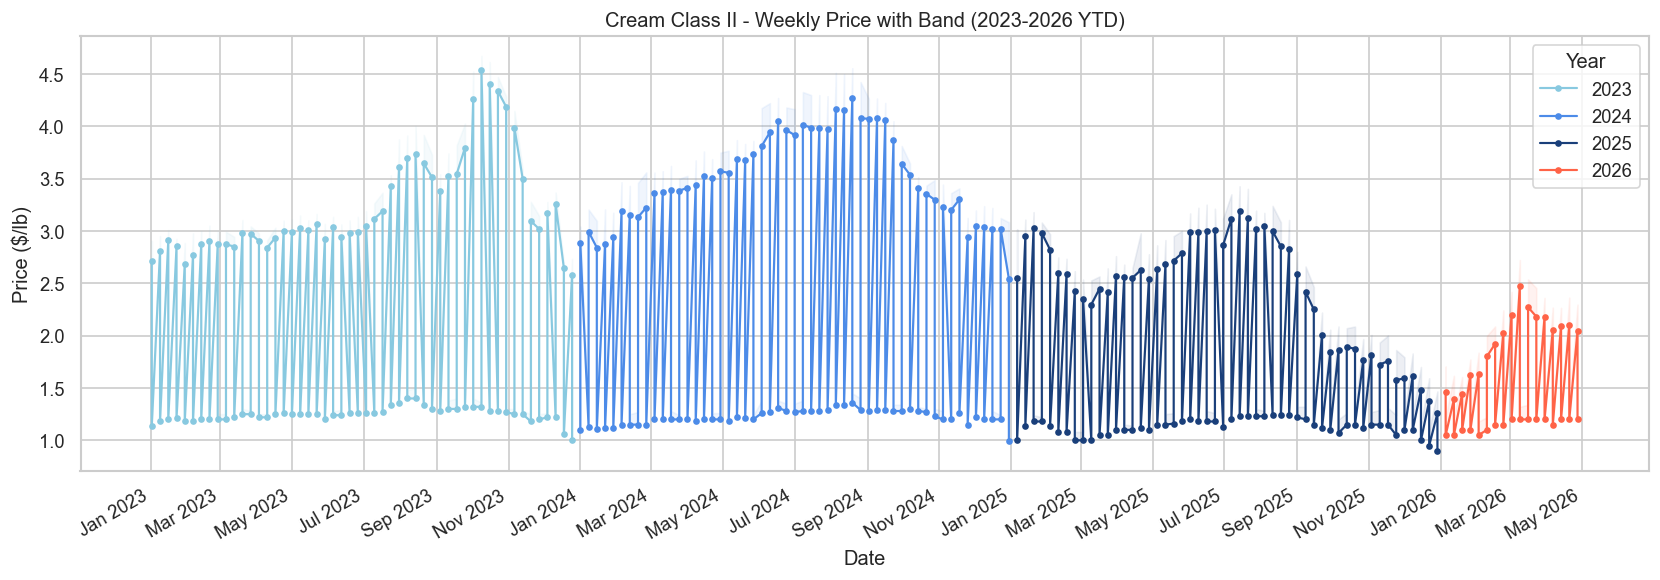

In [8]:
recent = df[df['year'] >= 2023].sort_values('report_date')
palette = {2023: '#88C9E0', 2024: '#4C8BE8', 2025: '#1A3F7A', 2026: 'tomato'}

fig, ax = plt.subplots(figsize=(14, 5))
for yr, ydf in recent.groupby('year'):
    ax.plot(ydf['report_date'], ydf['price_min'], marker='o', markersize=3,
            linewidth=1.3, label=str(yr), color=palette.get(yr, 'gray'))
    ax.fill_between(ydf['report_date'], ydf['price_min'], ydf['price_max'],
                    alpha=0.08, color=palette.get(yr, 'gray'))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/lb)')
ax.set_title('Cream Class II - Weekly Price with Band (2023-2026 YTD)')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

**What this means for you:**

This is the most actionable chart — it zooms into the last 3 years so you can see exactly what cream prices have been doing recently, week by week. Each colored line is a different year. The faint shaded band around each line shows the min-to-max range for that week.

- Where the lines **rise steeply**, cream was getting expensive fast.
- Where the lines **fall**, prices were easing — a good time to buy.
- When the **2026 red line** is above or below prior years at the same point on the calendar, it tells you whether this year is running hotter or cooler than normal.

**For Sneehee:** This is essentially your weekly price dashboard. If the red line (2026) is climbing through February and March at a steeper angle than 2024 or 2025 did, that's an early warning that your ingredient costs are going to hit harder this quarter.

## 8. Year-over-Year % Change in Annual Avg Price

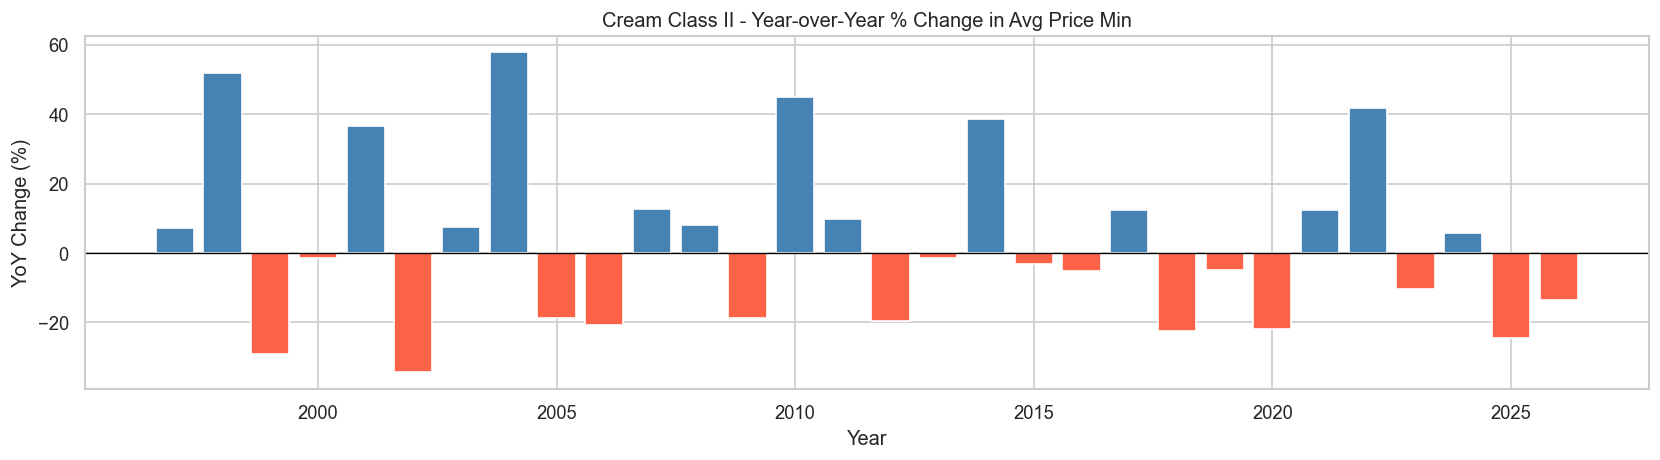

In [9]:
ann_avg = df.groupby('year')['price_min'].mean()
yoy = ann_avg.pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in yoy]
ax.bar(yoy.index, yoy.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('YoY Change (%)')
ax.set_title('Cream Class II - Year-over-Year % Change in Avg Price Min')
plt.tight_layout()
plt.show()

**What this means for you:**

This strips out the noise and asks one simple question: *compared to last year, did cream get cheaper or more expensive?*

- **Blue bars (above zero):** cream cost more than the previous year — your ingredient bill went up.
- **Red bars (below zero):** cream cost less than the previous year — you caught a break.

The height of the bar tells you how big the swing was. A bar at +30% means cream averaged 30% more expensive than the year before — that's a massive hit on your margins if you weren't prepared.

**Key insight:** The worst years weren't just expensive — they were *surprise* increases after calm periods. Notice how large blue spikes often follow a red or flat year. That pattern is exactly why relying on last year's prices to budget this year is dangerous. A forecasting tool that catches these inflection points early is the whole point of Orbbit.

## 9. Rolling 12-Week Average Price (2018-2026)

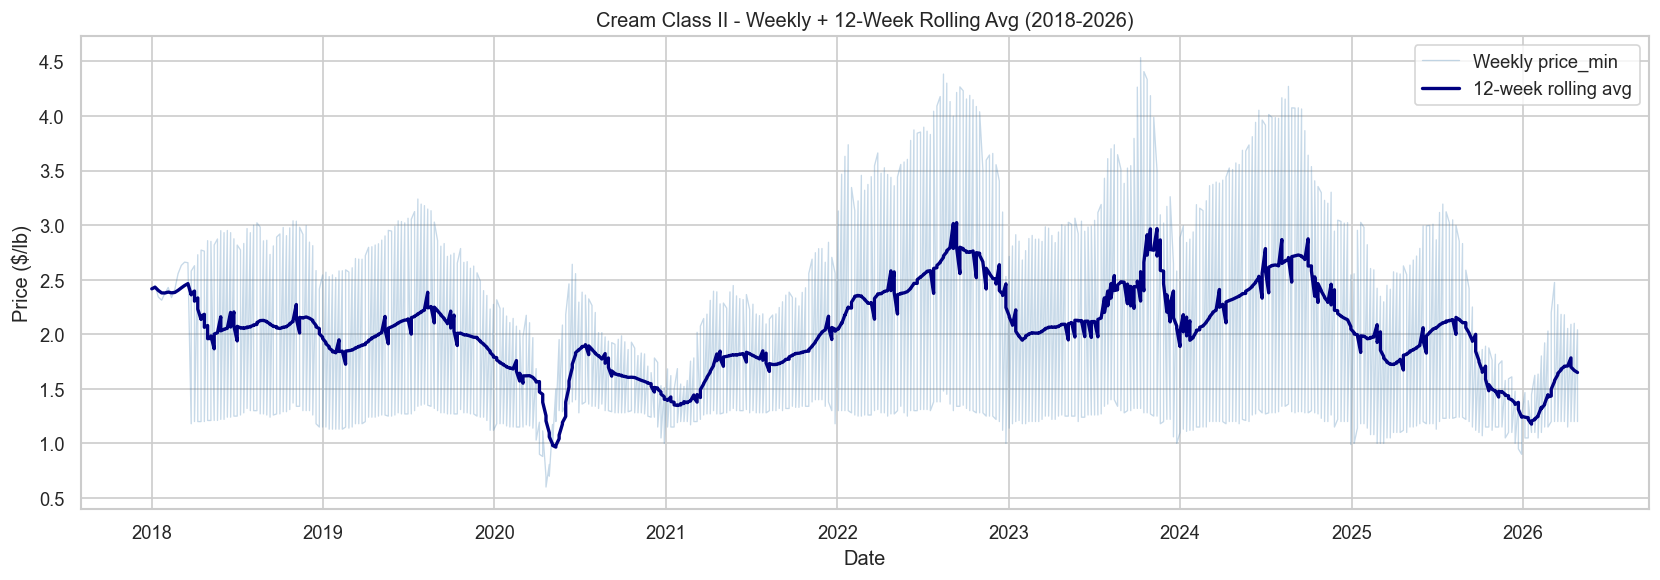

In [10]:
post2018 = df[df['year'] >= 2018].sort_values('report_date').copy()
post2018['rolling_12w'] = post2018['price_min'].rolling(12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(post2018['report_date'], post2018['price_min'], alpha=0.3,
        color='steelblue', linewidth=0.8, label='Weekly price_min')
ax.plot(post2018['report_date'], post2018['rolling_12w'],
        color='navy', linewidth=2, label='12-week rolling avg')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/lb)')
ax.set_title('Cream Class II - Weekly + 12-Week Rolling Avg (2018-2026)')
ax.legend()
plt.tight_layout()
plt.show()

**What this means for you:**

The faint line is the raw weekly price — it jumps around a lot. The bold dark line is the 12-week rolling average, which smooths out the week-to-week noise to reveal the true underlying trend.

Think of it like checking your weight daily vs. weekly. Day-to-day fluctuations are distracting. The rolling average shows you whether you're actually trending up or down.

- When the bold line is **rising**, the underlying trend is that cream is getting more expensive — time to renegotiate contracts or consider buying ahead.
- When the bold line is **falling**, the market is easing — you might wait before locking in long-term pricing.

**This is the signal our forecasting model extends forward.** The model learns from how this smoothed trend has behaved historically and projects where it's likely heading over the next 30, 60, or 90 days.

## 10. Rolling 12-Week Price Volatility (2018-2026)

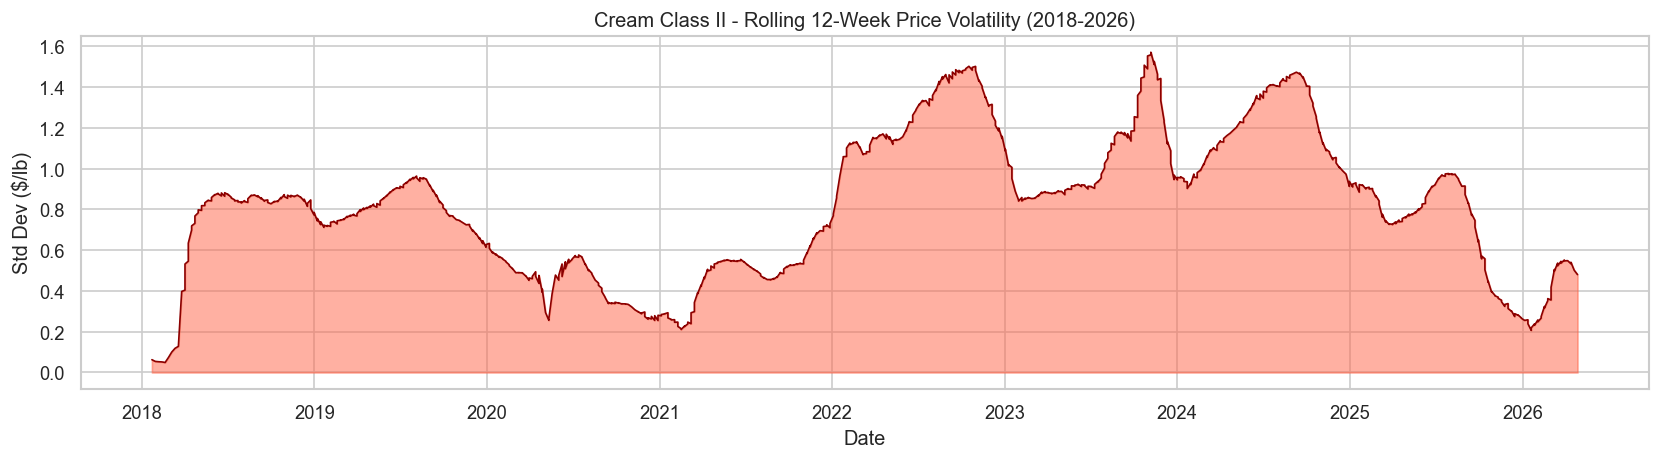

In [11]:
post2018['rolling_vol'] = post2018['price_min'].rolling(12, min_periods=4).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(post2018['report_date'], post2018['rolling_vol'],
                alpha=0.5, color='tomato')
ax.plot(post2018['report_date'], post2018['rolling_vol'], color='darkred', linewidth=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_xlabel('Date')
ax.set_ylabel('Std Dev ($/lb)')
ax.set_title('Cream Class II - Rolling 12-Week Price Volatility (2018-2026)')
plt.tight_layout()
plt.show()

**What this means for you:**

Volatility measures how wildly prices are swinging week to week. Think of it as a "turbulence meter" for cream prices.

- **Low and flat (near zero):** prices are calm and predictable — safe to plan ahead with confidence.
- **Tall spike:** prices were jumping around violently — dangerous for any business that buys cream regularly, because your costs could change dramatically from one order to the next.

The massive spike around **2021–2022** lines up with the post-COVID supply chain crisis — that period was extremely turbulent for dairy. You can see volatility has since come down but hasn't fully returned to the calm levels of 2018–2019.

**Why this matters for working capital:** High volatility = harder to budget = higher risk of a cash shortfall. This chart is part of what Orbbit's model uses to determine not just *where prices are going* but *how confident we are* in that forecast. When volatility is high, the confidence band around the forecast widens, and the recommendation to secure working capital becomes more urgent.